<a href="https://colab.research.google.com/github/lyl-0901/2048Project/blob/main/flight_delay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1.Background story and Introduction:**
## Project Proposal: Dynamic Risk Modeling for Flight Insurance

This is the current insurance plan I purchased for my flight:

| Insurance Coverage Item | Coverage Amount |
| :--- | :--- |
| **Accidental Death and Dismemberment (AD&D)** | 3,000,000 RMB |
| **Flight Delay** ($\ge 2$ hours and $< 4$ hours) | 100 RMB |
| **Flight Delay** ($\ge 4$ hours) | 300 RMB |
| **Flight Diversion or Return to Origin** | 200 RMB |


The current insurance fee is **fixed** and does not account for the specific conditions of each flight. Consequently, the insurance company faces varying levels of risk across different flights, while the premium remains constant.

The **stakeholders** for our project are these insurance companies. Our goal is to train a model to **predict the quantitative risk** for each individual flight. We will model the flight delay time ($D$) as a **random variable**, investigate its specific probability distribution for a given flight, and use this distribution to **value the risk** and dynamically adjust the insurance price accordingly.

## Expected Loss Calculation Model for Flight Insurance

This model can be used to caculate the **Expected Loss ($E[C]$)**, which represents the average anticipated payout cost for the insurance company per flight, based on the discrete probability distribution of the **Delay Time Random Category ($D$)**, which is our target variable.

---

### 1. Definition of the Random Variable and Distribution

Let $D$ be the Delay Time Random Variable (in hours), and $C$ be the corresponding Coverage Payout (RMB). The distribution and payouts are defined by the following categories:

| Index ($i$) | Delay Time Category ($D_i$) | Probability ($P_i = P(D_i)$) | Coverage Payout ($C_i = M_i$) |
| :---: | :--- | :--- | :--- |
| 0 | $D \le 0$ hours (On-time) | $P_0$ | $M_0=0$ |
| 1 | $0 < D \le 2$ hours | $P_1$ | $M_1$ |
| 2 | $2 \le D < 4$ hours | $P_2$ | $M_2$ |
| 3 | $D \ge 4$ hours | $P_3$ | $M_3$ |
| 4 | Canceled / Diversion / Other | $P_4$ | $M_4$ |

*Constraint: The sum of probabilities for all outcomes must equal one:*
$$
\sum_{i=0}^{4} P_i = 1
$$

### 2. Expected Loss Formula (Mathematical Expression)

The Expected Loss $E[C]$ is calculated as the sum of the products of the probability of each outcome and its corresponding coverage payout:

$$
E[C] = \sum_{i=0}^{4} P_i \cdot M_i
$$
# **We use the MSE of (predicted payout) and (real payout) to evaluate.**

# **2.Dataset and EDA**

In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np

# Download latest version
path_dir = kagglehub.dataset_download("shubhamsingh42/flight-delay-dataset-2018-2024")

print("Path to dataset directory:", path_dir)

file_name = "flight_data_2018_2024.csv"
path_to_file = os.path.join(path_dir, file_name)
df = pd.read_csv(path_to_file)

print("\nDataFrame shape:", df.shape)
print(df.head())

Using Colab cache for faster access to the 'flight-delay-dataset-2018-2024' dataset.
Path to dataset directory: /kaggle/input/flight-delay-dataset-2018-2024


/tmp/ipython-input-1965633559.py:13: DtypeWarning: Columns (11,13,86,93,94,101) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path_to_file)



DataFrame shape: (582425, 120)
   Year  Quarter  Month  DayofMonth  DayOfWeek  FlightDate  \
0  2024        1      1          14          7  2024-01-14   
1  2024        1      1          14          7  2024-01-14   
2  2024        1      1          14          7  2024-01-14   
3  2024        1      1          14          7  2024-01-14   
4  2024        1      1          14          7  2024-01-14   

  Marketing_Airline_Network Operated_or_Branded_Code_Share_Partners  \
0                        UA                            UA_CODESHARE   
1                        UA                            UA_CODESHARE   
2                        UA                            UA_CODESHARE   
3                        UA                            UA_CODESHARE   
4                        UA                            UA_CODESHARE   

   DOT_ID_Marketing_Airline IATA_Code_Marketing_Airline  ...  Div5Airport  \
0                     19977                          UA  ...          NaN   
1             

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582425 entries, 0 to 582424
Columns: 120 entries, Year to Unnamed: 119
dtypes: float64(70), int64(23), object(27)
memory usage: 533.2+ MB


This dataset has 120 features, however we only focus on some features that are known and could be used for predicting the dely time before the flight.
#### 1. ✈️ Carrier Aspect

Used to identify the airline brand and operational entity, capturing inherent delay tendencies and operational efficiency.

* `Marketing_Airline_Network`: Unique Marketing Carrier Code.

#### 2. 🗓️ Temporal Aspect

Used to capture seasonal variations, weekly trends, holiday effects, and the influence of the time of day on delays.

* `Quarter`: Quarter of the Year (1-4).
* `Month`: Month of the Year.
* `DayofMonth`: Day of the Month.
* `DayOfWeek`: Day of the Week.
* `CRSDepTime`: CRS Departure Time (local time: hhmm). **(Planned time of departure)**

#### 3. 🗺️ Route & Location Aspect

Used to capture the impact of airport congestion, route distance, and regional complexity on flight schedules.

* `OriginAirportID`: Origin Airport ID.
* `DestAirportID`: Destination Airport ID.
* `OriginCityMarketID`: Origin Airport, City Market ID.
* `DestCityMarketID`: Destination Airport, City Market ID.
* `Distance`: Distance between airports (miles).

---

**Total Features:** Our model will primarily use these **10 features** as input to predict the probability distribution of flight delay times.

**Target variable:**  The combination of:

* `ArrDelayMinutes`: Difference in minutes between scheduled and actual arrival time. Early arrivals are set to 0. (We will assign them into different bins!)
* `Cancelled`: Cancelled Flight Indicator (1=Yes)
* `Diverted`: Diverted Flight Indicator (1=Yes)

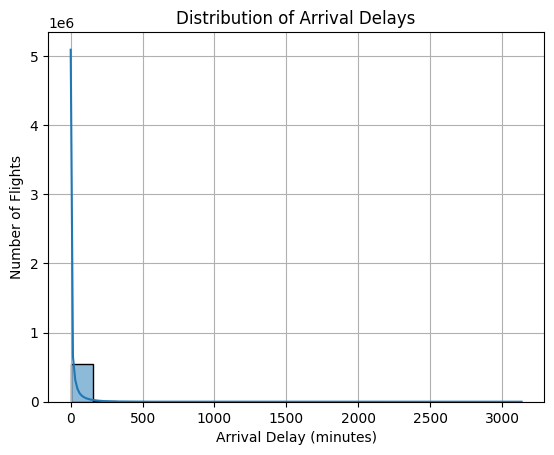

,ArrDelayMinutes
count,558715.000000
mean,19.567187
std,65.207219
min,0.000000
25%,0.000000
50%,0.000000
75%,13.000000
max,3136.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.histplot(df['ArrDelayMinutes'], bins=20, kde=True)

plt.title('Distribution of Arrival Delays')  # 📍 Chart title
plt.xlabel('Arrival Delay (minutes)')        # 🏷️ X-axis: Delay time
plt.ylabel('Number of Flights')              # 🏷️ Y-axis: Count of flights
plt.grid(True)
plt.show()
df["ArrDelayMinutes"].describe()

In [ ]:
print(df['Cancelled'].value_counts())
print(df['Diverted'].value_counts())

Cancelled
0.0    560352
1.0     22073
Name: count, dtype: int64
Diverted
0.0    580788
1.0      1637
Name: count, dtype: int64


In [ ]:
df['Marketing_Airline_Network'].value_counts()

,count
Marketing_Airline_Network,
AA,147443
DL,116199
WN,115389
UA,104791
AS,29057
NK,20415
B6,19580
F9,14379
G4,8596


<Axes: xlabel='Distance', ylabel='Count'>

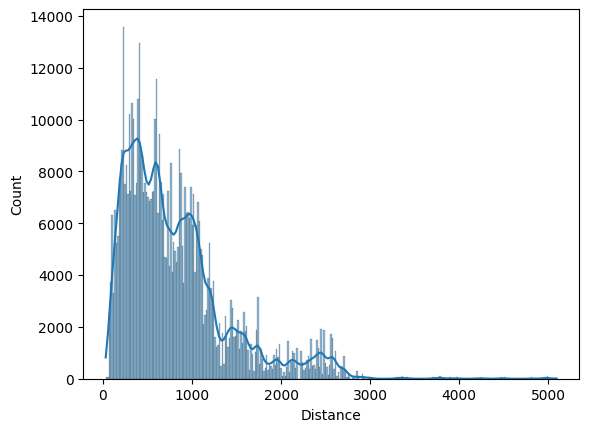

In [ ]:
sns.histplot(data=df['Distance'],kde=True)

In [ ]:
#1 data cleanning:
input_features = [
    'Marketing_Airline_Network', 'Quarter', 'Month', 'DayofMonth',
    'DayOfWeek', 'CRSDepTime', 'OriginAirportID', 'DestAirportID',
    'OriginCityMarketID', 'DestCityMarketID', 'Distance'
]

target_features = [
    'ArrDelayMinutes', 'Cancelled', 'Diverted'
]
df_clean = df[input_features + target_features]

bin1 = 60
bin2 = 120

# 0: OnTime/Early, 1: Minor Delay, 2: Significant Delay, 3: Major Delay, 4: Flight Event
df_clean['Delay_Category'] = -1
df_clean.loc[(df_clean['Cancelled'] == 1) | (df_clean['Diverted'] == 1), 'Delay_Category'] = 4
df_clean.loc[(df_clean['Delay_Category'] != 4) & (df_clean['ArrDelayMinutes'] >= bin2), 'Delay_Category'] = 3
df_clean.loc[(df_clean['Delay_Category'] != 4) & (df_clean['ArrDelayMinutes'] >= bin1) & (df_clean['ArrDelayMinutes'] < bin2), 'Delay_Category'] = 2
df_clean.loc[(df_clean['Delay_Category'] != 4) & (df_clean['ArrDelayMinutes']> 0)& (df_clean['ArrDelayMinutes'] < bin1), 'Delay_Category'] = 1
df_clean.loc[(df_clean['Delay_Category'] != 4) & (df_clean['ArrDelayMinutes'] == 0), 'Delay_Category'] = 0
df_clean=df_clean[df_clean['Delay_Category']!=-1]

df_clean = df_clean.drop(columns=target_features)

CATEGORICAL_FEATURES = [
    'Marketing_Airline_Network', 'Quarter', 'Month', 'DayofMonth',
    'DayOfWeek', 'OriginAirportID', 'DestAirportID', 'OriginCityMarketID',
    'DestCityMarketID'
]


for col in CATEGORICAL_FEATURES:
    df_clean[col] = df_clean[col].astype('category')

def time_to_block(time_hhmm):
    hour = time_hhmm // 100
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df_clean['CRSDepTime_Block'] = df_clean['CRSDepTime'].apply(time_to_block).astype('category')
df_clean['CRSDepTime'] = df_clean['CRSDepTime'] // 100 * 60 + df_clean['CRSDepTime'] % 100
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582425 entries, 0 to 582424
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   Marketing_Airline_Network  582425 non-null  category
 1   Quarter                    582425 non-null  category
 2   Month                      582425 non-null  category
 3   DayofMonth                 582425 non-null  category
 4   DayOfWeek                  582425 non-null  category
 5   CRSDepTime                 582425 non-null  int64   
 6   OriginAirportID            582425 non-null  category
 7   DestAirportID              582425 non-null  category
 8   OriginCityMarketID         582425 non-null  category
 9   DestCityMarketID           582425 non-null  category
 10  Distance                   582425 non-null  float64 
 11  Delay_Category             582425 non-null  int64   
 12  CRSDepTime_Block           582425 non-null  category
dtypes: category(10

In [ ]:
df['Marketing_Airline_Network'].isna().sum()

np.int64(0)

In [ ]:
df['Marketing_Airline_Network'].value_counts()

,count
Marketing_Airline_Network,
AA,147443
DL,116199
WN,115389
UA,104791
AS,29057
NK,20415
B6,19580
F9,14379
G4,8596


# **3.Modeling**


In [ ]:
!pip install scikit-learn

In [ ]:
df_clean['Delay_Category'].value_counts()

,count
Delay_Category,
0,336861
1,172087
2,28170
4,23710
3,21597


In [ ]:
len(df_clean[df_clean['Delay_Category']==0])/len(df_clean)

0.5783766150148087

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, log_loss
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from pandas.errors import SettingWithCopyWarning


# --- Assuming df_clean has been generated by your data cleaning code ---
X = df_clean.drop(columns=['Delay_Category'])
y = df_clean['Delay_Category']
NUM_CLASSES = 5

# ======================================================================
# 0. Define Payout Structure and Cost Function
# ======================================================================

# Define Payout for each category (Y_actual)
PAYOUT_MAP = {
    0: 0,
    1: 50,
    2: 100,
    3: 300,
    4: 200
}

def calculate_expected_payout_mse(y_true_categories, y_proba):
    """
    Calculates the Mean Squared Error between the Actual Payout and the Expected Payout.

    Y_expected = SUM [ P(Cat_i) * Payout_i ]
    Loss = MSE(Y_expected, Y_actual)
    """
    # 1. Calculate Actual Payout (Y_actual)
    y_actual_payout = y_true_categories.map(PAYOUT_MAP).values

    # 2. Calculate Expected Payout (Y_expected)
    # y_proba is N x 5 matrix. Payout vector is 5 x 1.
    payout_vector = np.array([PAYOUT_MAP[i] for i in range(NUM_CLASSES)])
    y_expected_payout = np.dot(y_proba, payout_vector)

    # 3. Calculate Custom MSE Loss
    custom_mse = mean_squared_error(y_actual_payout, y_expected_payout)
    return custom_mse, y_actual_payout, y_expected_payout

# ======================================================================
# 1. Define Model and Preprocessor (Log Loss optimized structure)
# ======================================================================

NUMERICAL_FEATURES = ['Distance','CRSDepTime']
CATEGORICAL_FEATURES = X.select_dtypes(include='category').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
             ('log', FunctionTransformer(lambda x: np.log1p(x), validate=False)),
             ('scaler', StandardScaler())]), NUMERICAL_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES)
    ], remainder='drop'
)

xgb_model = XGBClassifier(
    objective='multi:softprob', eval_metric='mlogloss', n_estimators=300,
    max_depth=7, learning_rate=0.05, num_class=NUM_CLASSES, reg_lambda=1,
    use_label_encoder=False, random_state=42, n_jobs=-1, tree_method='hist'
)

N_SPLITS = 3
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
# ======================================================================
# 2. Run Baseline Model (Prior Probability Baseline)
# ======================================================================

print("--- 1. Running Baseline Model (Custom Payout MSE) ---")
dummy_model = DummyClassifier(strategy='prior', random_state=42)
cv_custom_mse_baseline = []
cv_logloss_baseline = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    dummy_model.fit(X_train, y_train)
    y_pred_proba = dummy_model.predict_proba(X_test)

    # Calculate Custom MSE for Baseline
    custom_mse, y_actual, y_expected = calculate_expected_payout_mse(y_test, y_pred_proba)
    logloss = log_loss(y_test, y_pred_proba)

    cv_custom_mse_baseline.append(custom_mse)
    cv_logloss_baseline.append(logloss)

mean_custom_mse_baseline = np.mean(cv_custom_mse_baseline)
mean_logloss_baseline = np.mean(cv_logloss_baseline)

print(f"Mean CV Baseline Custom Payout MSE: {mean_custom_mse_baseline:.2f}")
print(f"Mean CV Baseline Standard Log Loss: {mean_logloss_baseline:.4f}")
print("-" * 70)


# ======================================================================
# 3. Run Log Loss Optimized XGBoost Model (Custom Payout MSE Evaluation)
# ======================================================================

print("--- 2. Running XGBoost Model (Evaluating with Custom Payout MSE) ---")
cv_custom_mse_xgb = []
fold_no = 1

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    # Train XGBoost Model (Optimized for Log Loss, which provides best P_i)
    xgb_model.fit(X_train_processed, y_train)

    # Prediction
    y_pred_proba = xgb_model.predict_proba(X_test_processed)

    # Calculate Custom MSE for XGBoost
    custom_mse, y_actual, y_expected = calculate_expected_payout_mse(y_test, y_pred_proba)

    cv_custom_mse_xgb.append(custom_mse)

    print(f"Fold {fold_no} Custom Payout MSE: {custom_mse:.2f}")

    fold_no += 1

mean_custom_mse_xgb = np.mean(cv_custom_mse_xgb)
print("-" * 70)


# ======================================================================
# 4. Final Results Comparison
# ======================================================================

print("--- 3. Final Performance Comparison (Focusing on Payout MSE) ---")

results = pd.DataFrame({
    'Metric': ['Custom Payout MSE'],
    'Baseline (Prior)': [mean_custom_mse_baseline],
    'XGBoost (Optimized)': [mean_custom_mse_xgb],
    'Improvement (vs. Baseline)': [mean_custom_mse_baseline - mean_custom_mse_xgb]
})

print(results.to_markdown(index=False, floatfmt=".2f"))

if mean_custom_mse_xgb < mean_custom_mse_baseline:
    print("\nConclusion: XGBoost significantly reduces the Custom Payout MSE, meaning the model accurately predicts the expected cost.")
else:
    print("\nWarning: Custom Payout MSE failed to beat the baseline.")

--- 1. Running Baseline Model (Custom Payout MSE) ---
Mean CV Baseline Custom Payout MSE: 4676.65
Mean CV Baseline Standard Log Loss: 1.0759
----------------------------------------------------------------------
--- 2. Running XGBoost Model (Evaluating with Custom Payout MSE) ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:55:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1 Custom Payout MSE: 3707.64


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:56:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2 Custom Payout MSE: 3692.62


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:56:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 3 Custom Payout MSE: 3676.71
----------------------------------------------------------------------
--- 3. Final Performance Comparison (Focusing on Payout MSE) ---
| Metric                           |   Baseline (Prior) | XGBoost (Optimized)   | Improvement (vs. Baseline)   |
|:---------------------------------|-------------------:|:----------------------|:-----------------------------|
| Custom Payout MSE                |            4676.65 | 3692.323783880543     | 984.3228116924834            |
| Standard Log Loss (XGBoost Only) |               1.08 | N/A                   | N/A                          |

Conclusion: XGBoost significantly reduces the Custom Payout MSE, meaning the model accurately predicts the expected cost.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, log_loss
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from pandas.errors import SettingWithCopyWarning

import warnings
warnings.filterwarnings("ignore", category=SettingWithCopyWarning)

NUM_CLASSES = 5

# ======================================================================
# 1. Define Payout Structure and Cost Function
# ======================================================================

# Define Payout for each category (Y_actual)
PAYOUT_MAP = {
    0: 0,
    1: 50,
    2: 100,
    3: 300,
    4: 200
}

def calculate_expected_payout_mse(y_true_categories, y_proba):
    """
    Calculates the Mean Squared Error between the Actual Payout and the Expected Payout.
    """
    # 1. Calculate Actual Payout (Y_actual)
    y_actual_payout = y_true_categories.map(PAYOUT_MAP).values

    # 2. Calculate Expected Payout (Y_expected)
    payout_vector = np.array([PAYOUT_MAP[i] for i in range(NUM_CLASSES)])
    y_expected_payout = np.dot(y_proba, payout_vector)

    # 3. Calculate Custom MSE Loss
    custom_mse = mean_squared_error(y_actual_payout, y_expected_payout)
    return custom_mse, y_actual_payout, y_expected_payout

# ======================================================================
# 2. Define Model and Preprocessor
# ======================================================================

NUMERICAL_FEATURES = ['Distance','CRSDepTime']
CATEGORICAL_FEATURES = X.select_dtypes(include='category').columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
             ('log', FunctionTransformer(lambda x: np.log1p(x), validate=False)),
             ('scaler', StandardScaler())]), NUMERICAL_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES)
    ], remainder='drop'
)

xgb_model = XGBClassifier(
    objective='multi:softprob', eval_metric='mlogloss', n_estimators=300,
    max_depth=7, learning_rate=0.05, num_class=NUM_CLASSES, reg_lambda=1,
    use_label_encoder=False, random_state=42, n_jobs=-1, tree_method='hist'
)

N_SPLITS = 3
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# ======================================================================
# 3. Run Baseline Model (Prior Probability Baseline)
# ======================================================================

print("--- 1. Running Baseline Model (Custom Payout MSE) ---")
dummy_model = DummyClassifier(strategy='prior', random_state=42)
cv_custom_mse_baseline = []
cv_logloss_baseline = []

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    dummy_model.fit(X_train, y_train)
    y_pred_proba = dummy_model.predict_proba(X_test)

    # Calculate Custom MSE for Baseline
    custom_mse, y_actual, y_expected = calculate_expected_payout_mse(y_test, y_pred_proba)
    logloss = log_loss(y_test, y_pred_proba)

    cv_custom_mse_baseline.append(custom_mse)
    cv_logloss_baseline.append(logloss)

mean_custom_mse_baseline = np.mean(cv_custom_mse_baseline)
mean_logloss_baseline = np.mean(cv_logloss_baseline)

print(f"Mean CV Baseline Custom Payout MSE: {mean_custom_mse_baseline:.2f}")
print(f"Mean CV Baseline Standard Log Loss: {mean_logloss_baseline:.4f}")
print("-" * 70)

# ======================================================================
# 4. Run Weighted XGBoost Model (Optimized with Sample Weights)
# ======================================================================

print("--- 2. Running XGBoost Model (Optimized with Sample Weights) ---")

# --- CORE STEP: Pre-calculate the actual payout amount for all samples ---
# This array will be used to generate weights for the training folds.
y_payouts = y.map(PAYOUT_MAP).values

cv_custom_mse_xgb_weighted = []
fold_no = 1

for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Extract sample weights for the training set
    weights_train = y_payouts[train_index]+1000

    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    # Key modification: Train the model using sample_weight
    xgb_model.fit(
        X_train_processed,
        y_train,
        sample_weight=weights_train # <-- Pass sample weights here
    )

    # Prediction
    y_pred_proba = xgb_model.predict_proba(X_test_processed)

    # Evaluation (Still using Custom Payout MSE for reporting)
    custom_mse, y_actual, y_expected = calculate_expected_payout_mse(y_test, y_pred_proba)

    cv_custom_mse_xgb_weighted.append(custom_mse)

    print(f"Fold {fold_no} Weighted XGBoost Custom Payout MSE: {custom_mse:.2f}")

    fold_no += 1

mean_custom_mse_xgb_weighted = np.mean(cv_custom_mse_xgb_weighted)
print("-" * 70)


# ======================================================================
# 5. Final Results Comparison
# ======================================================================

print("--- 3. Final Performance Comparison (Focusing on Payout MSE) ---")

results = pd.DataFrame({
    'Metric': ['Custom Payout MSE'],
    'Baseline (Prior)': [mean_custom_mse_baseline],
    'XGBoost (Weighted)': [mean_custom_mse_xgb_weighted],
    'Improvement (vs. Baseline)': [mean_custom_mse_baseline - mean_custom_mse_xgb_weighted]
})

print(results.to_markdown(index=False, floatfmt=".2f"))

if mean_custom_mse_xgb_weighted < mean_custom_mse_baseline:
    print("\nConclusion: The Weighted XGBoost successfully reduces the Custom Payout MSE, meaning the model is better at predicting high-cost events.")
else:
    print("\nWarning: The Weighted XGBoost failed to beat the baseline.")

--- 1. Running Baseline Model (Custom Payout MSE) ---
Mean CV Baseline Custom Payout MSE: 4676.65
Mean CV Baseline Standard Log Loss: 1.0759
----------------------------------------------------------------------
--- 2. Running XGBoost Model (Optimized with Sample Weights) ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:59:08] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1 Weighted XGBoost Custom Payout MSE: 3705.61


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:59:26] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 2 Weighted XGBoost Custom Payout MSE: 3677.01


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:59:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 3 Weighted XGBoost Custom Payout MSE: 3669.19
----------------------------------------------------------------------
--- 3. Final Performance Comparison (Focusing on Payout MSE) ---
| Metric            |   Baseline (Prior) |   XGBoost (Weighted) |   Improvement (vs. Baseline) |
|:------------------|-------------------:|---------------------:|-----------------------------:|
| Custom Payout MSE |            4676.65 |              3683.93 |                       992.71 |

Conclusion: The Weighted XGBoost successfully reduces the Custom Payout MSE, meaning the model is better at predicting high-cost events.
